In [1]:
from google.colab import drive
import shutil
import os

# Force remount Google Drive to ensure fresh connection
print("Attempting to force remount Google Drive...")
drive.mount('/content/drive', force_remount=True)
print("Google Drive remounted.")

source_dir_drive = '/content/drive/MyDrive/_Phase3' # Source directory on Google Drive
dest_dir_colab = '/content' # Target base directory in Colab to copy contents into

# Check if the source directory exists before proceeding
if not os.path.exists(source_dir_drive):
    print(f"Error: Source directory '{source_dir_drive}' does not exist on Google Drive AFTER remount. Please verify its presence manually.")
else:
    print(f"Source directory '{source_dir_drive}' found after remount. Contents:")
    source_items = []
    try:
        source_items = os.listdir(source_dir_drive)
        for item in source_items:
            print(f" - {item}")
    except Exception as e:
        print(f"Could not list contents of '{source_dir_drive}': {e}")

    # Copy contents of source_dir_drive directly into dest_dir_colab
    try:
        print(f"Copying contents of '{source_dir_drive}' directly into '{dest_dir_colab}'.")
        for item in source_items:
            source_item_path = os.path.join(source_dir_drive, item)
            dest_item_path = os.path.join(dest_dir_colab, item)

            # If item already exists in destination, remove it to avoid errors
            if os.path.exists(dest_item_path):
                if os.path.isdir(dest_item_path):
                    shutil.rmtree(dest_item_path)
                    print(f"Removed existing directory '{dest_item_path}'.")
                else:
                    os.remove(dest_item_path)
                    print(f"Removed existing file '{dest_item_path}'.")

            if os.path.isdir(source_item_path):
                shutil.copytree(source_item_path, dest_item_path)
            else:
                shutil.copy2(source_item_path, dest_item_path)
            print(f"Copied '{source_item_path}' to '{dest_item_path}'.")
        print(f"✅ Successfully copied contents of '{source_dir_drive}' to '{dest_dir_colab}'.")

    except Exception as e:
        print(f"⚠️ An error occurred during directory contents copy: {e}")

Attempting to force remount Google Drive...
Mounted at /content/drive
Google Drive remounted.
Source directory '/content/drive/MyDrive/_Phase3' found after remount. Contents:
 - phase3
 - output
 - samples
 - render_plan.py
 - audit_plan.py
 - phase3_run.py
Copying contents of '/content/drive/MyDrive/_Phase3' directly into '/content'.
Copied '/content/drive/MyDrive/_Phase3/phase3' to '/content/phase3'.
Copied '/content/drive/MyDrive/_Phase3/output' to '/content/output'.
Copied '/content/drive/MyDrive/_Phase3/samples' to '/content/samples'.
Copied '/content/drive/MyDrive/_Phase3/render_plan.py' to '/content/render_plan.py'.
Copied '/content/drive/MyDrive/_Phase3/audit_plan.py' to '/content/audit_plan.py'.
Copied '/content/drive/MyDrive/_Phase3/phase3_run.py' to '/content/phase3_run.py'.
✅ Successfully copied contents of '/content/drive/MyDrive/_Phase3' to '/content'.


In [2]:
!pip install anthropic
print("✴️ Anthropic installed!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 763.1/763.1 kB 12.4 MB/s eta 0:00:00
✴️ Anthropic installed!


In [ ]:
# !pip install whisperx openai-whisper
# print("✅ whisperx and openai-whisper installed!")

In [3]:
!apt-get install -y fonts-hosny-amiri
!fc-cache -fv
print("𝓐 𝓜 𝓲 ℛ 𝑰 Amiri fonts installed!")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-hosny-amiri
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 591 kB of archives.
After this operation, 2,638 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 fonts-hosny-amiri all 0.113-1 [591 kB]
Fetched 591 kB in 0s (2,731 kB/s)
Selecting previously unselected package fonts-hosny-amiri.
(Reading database ... 118252 files and directories currently installed.)
Preparing to unpack .../fonts-hosny-amiri_0.113-1_all.deb ...
Unpacking fonts-hosny-amiri (0.113-1) ...
Setting up fonts-hosny-amiri (0.113-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 2 dirs
/usr/share/fonts/opentype: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/opentype/fonts-hosny-amiri: caching, new cache conten

In [4]:
!pip install arabic-reshaper python-bidi
print("✅ Arabic_reshaper and python-bidi installed!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 7.4 MB/s eta 0:00:00
✅ Arabic_reshaper and python-bidi installed!


Amiri-Regular.ttf added to font manager: /usr/share/fonts/opentype/fonts-hosny-amiri/Amiri-Regular.ttf
Matplotlib font cache cleared and rebuilt.


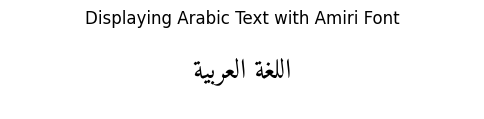

In [5]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import arabic_reshaper
from bidi.algorithm import get_display
import os

# --- Step 1: Add Amiri font to Matplotlib's font manager explicitly ---
# The font is installed at /usr/share/fonts/opentype/fonts-hosny-amiri/
font_path_base = '/usr/share/fonts/opentype/fonts-hosny-amiri/'
amiri_regular_path = os.path.join(font_path_base, 'Amiri-Regular.ttf')

# Ensure the font file exists before trying to add it
if os.path.exists(amiri_regular_path):
    fm.fontManager.addfont(amiri_regular_path)
    print(f"Amiri-Regular.ttf added to font manager: {amiri_regular_path}")
else:
    print(f"Warning: Amiri-Regular.ttf not found at expected path: {amiri_regular_path}")

# Clear and rebuild matplotlib's font cache to ensure all fonts are properly registered
# Removed 'try_read_cache=False' as it's not supported in some matplotlib versions.
fm._load_fontmanager() # Reload font manager
fm._get_fontconfig_fonts() # Re-read font configuration
print("Matplotlib font cache cleared and rebuilt.")

# Arabic text to display
arabic_text = "اللغة العربية"

# Reshape and reorder Arabic text for correct display (RTL and ligatures)
reshaped_text = arabic_reshaper.reshape(arabic_text)
rtl_text = get_display(reshaped_text)

# Create a dummy plot to display the text
fig, ax = plt.subplots(figsize=(6, 1))

# Use FontProperties to explicitly specify the font file for the text
# This bypasses potential issues with font family naming and ensures Amiri is used.
ax.text(0.5, 0.5, rtl_text, ha='center', va='center', fontsize=20,
        fontproperties=fm.FontProperties(fname=amiri_regular_path))

ax.set_axis_off()
ax.set_title("Displaying Arabic Text with Amiri Font")
plt.show()

In [6]:
!python -c "from phase3.typography import FONT_PATHS; print(FONT_PATHS)"
print("✅ Pre-testingvthe discovery of Amiri fonts completed!")

Amiri not found on system — downloading from upstream
{'regular': '/root/.cache/lamahat/fonts/amiri-1.003/Amiri-Regular.ttf', 'bold': '/root/.cache/lamahat/fonts/amiri-1.003/Amiri-Bold.ttf', 'italic': '/root/.cache/lamahat/fonts/amiri-1.003/Amiri-Italic.ttf', 'bold_italic': '/root/.cache/lamahat/fonts/amiri-1.003/Amiri-BoldItalic.ttf', 'quran': '/root/.cache/lamahat/fonts/amiri-1.003/AmiriQuran.ttf'}
✅ Pre-testingvthe discovery of Amiri fonts completed!


In [7]:
print("Retrieving the Anthropic & Pexels API keys ...")
from google.colab import userdata
import os

# Retrieve the Anthropic API key from Colab Secrets
anthropic_api_key = userdata.get('ANTHROPIC_API_KEY')
pexels_api_key = userdata.get('PEXELS_API_KEY')

# Set it as an environment variable for phase3_run.py to use
if anthropic_api_key:
    os.environ['ANTHROPIC_API_KEY'] = anthropic_api_key
    print("🔑 Anthropic API key loaded from secrets and set as environment variable.")
else:
    print("❌ Warning: ANTHROPIC_API_KEY not found in Colab Secrets. Please ensure it's set correctly.")

if pexels_api_key:
    os.environ['PEXELS_API_KEY'] = pexels_api_key
    print("🔑 Pexels API key loaded from secrets and set as environment variable.")
else:
    print("❌ Warning: PEXELS_API_KEY not found in Colab Secrets. Please ensure it's set correctly.")

Retrieving the Anthropic & Pexels API keys ...
🔑 Anthropic API key loaded from secrets and set as environment variable.
🔑 Pexels API key loaded from secrets and set as environment variable.


In [8]:
# Confirm alignment works (interpolation backend — no install needed)
!python phase3_run.py \
    --script samples/al_askari_script.txt \
    --audio output/al_askari_audio.mp3 \
    --align-only \
    --align-backend interpolated

print("✅ Confirming alignment completed!")


Script : samples/al_askari_script.txt  (4,045 chars)

Script : 653 word tokens, 2 sections
Audio  : output/al_askari_audio.mp3
Total  : 391.0 s
Backend: interpolated

── Running alignment ──────────────────────────────────────────────
WARNING  phase3.align  Using interpolated timings — character-rate estimates only. For real word-level accuracy, install whisperx (pip install whisperx) or whisper (pip install openai-whisper).

  Aligned 653 words in 0.0 s
  Backend used: interpolated

── First 30 word timings ──────────────────────────────────────────
     0.00s →    1.18s   (1.18s)   مُذَكِّرات
     1.18s →    1.65s   (0.47s)   جعفر
     1.65s →    2.60s   (0.95s)   العسكريْ
     2.60s →    2.95s   (0.35s)   رجل
     2.95s →    3.43s   (0.47s)   واحد
     3.43s →    3.78s   (0.35s)   حمل
     3.78s →    4.49s   (0.71s)   سلاحاً
     4.49s →    4.73s   (0.24s)   من
     4.73s →    5.08s   (0.35s)   أجل
     5.08s →    5.67s   (0.59s)   تحرير
     5.67s →    6.26s   (0.59s)   وطنه،
    

In [9]:
# Regenerate the plan with the fixes
!python phase3_run.py \
    --script  samples/al_askari_script.txt \
    --audio   output/al_askari_audio.mp3 \
    --book-title "مذكرات جعفر العسكري" \
    --character-name "Jafar al-Askari" \
    --plan-only \
    --save-plan output/al_askari_plan_v2.json

print("✅ Regenerating the plan completed!")


Script : samples/al_askari_script.txt  (4,045 chars)

Script : 653 word tokens, 2 sections
Audio  : output/al_askari_audio.mp3
Total  : 391.0 s

── Step 1: Forced alignment ───────────────────────────────────────
WARNING  phase3.align  Backend whisperx failed: No module named 'whisperx'
WARNING  phase3.align  Backend whisper failed: No module named 'whisper'
WARNING  phase3.align  Using interpolated timings — character-rate estimates only. For real word-level accuracy, install whisperx (pip install whisperx) or whisper (pip install openai-whisper).
  653 words aligned via interpolated (0.0s)

── Step 2: AI shot planner ────────────────────────────────────────
INFO  phase3.plan  Calling claude-sonnet-4-6 for shot plan (target=65 shots, 5.0s avg, 391.0s total)
INFO  httpx  HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"
INFO  phase3.plan  Normalised 4 shot(s) with conflicting fields
INFO  phase3.plan  Clipping shot 379.54-391.00s to 391.00s (audio end)
INFO  p

In [10]:
# Audit it
!python audit_plan.py output/al_askari_plan_v2.json
# Expect: ~43 shots, <10% auto-split

print("✅ Audit completed!")

PLAN AUDIT

Total shots:        43
Plan timeline:      0.00s → 391.00s (391.0s)
Average shot:       9.09s
Range:              4.49s – 12.17s

✓  No gaps or overlaps

Visual types:
   typography      15 (  35%) ██████████
   archive          8 (  19%) █████
   portrait         7 (  16%) ████
   broll            4 (   9%) ██
   section_mark     4 (   9%) ██
   location         3 (   7%) ██
   title_card       2 (   5%) █

Motion types:
   static_hold     28 (  65%) ███████████████████
   slow_push       13 (  30%) █████████
   pan_right        2 (   5%) █

Section coverage:
   opening         33 shots
   closing         10 shots

✓  Auto-split shots: 6/43 (14%) from 6 original(s)
     Implied original Sonnet shot count: 43

Typography texts: 21 unique (21 occurrences after splits)
   Word count: min=3, max=22, avg=11.4
   Templates: chapter_heading:6, pull_quote:15


Search queries: 22 non-empty, avg 7.5 words
   ✓ Bare (1–2 words): 0 (none — good specificity)

✅ Audit completed!


In [11]:
# Run the script silently into the log file (Remove %%capture and --verbose)
!python render_plan.py \
    --plan   output/al_askari_plan_v2.json \
    --audio  output/al_askari_audio.mp3 \
    --output output/final_cut.mp4 \
    --anthropic-key $ANTHROPIC_API_KEY \
    --pexels-key   $PEXELS_API_KEY \
    --book-title   "مذكرات جعفر العسكري" \
    --character-name "Jafar al-Askari" \
    > output/render.log 2>&1 &


In [12]:
import time
from IPython.display import clear_output

log_path = "output/render.log"

print("Monitoring rendering progress...")
while True:
    try:
        # Read the log file contents
        try:
            with open(log_path, "r") as f:
                log_content = f.read()
        except FileNotFoundError:
            log_content = ""

        # Clear cell output and show the last 20 lines
        clear_output(wait=True)
        lines = log_content.splitlines()
        print("\n".join(lines[-20:]))

        # Check if the script's success signature is in the log
        if "Done in" in log_content or "Rendered video →" in log_content:
            print("\n✅ Rendering process completed successfully! Stopped monitoring.")
            break

        time.sleep(5)

    except KeyboardInterrupt:
        print("\n⚠️ Monitoring stopped manually. The script may still be running.")
        break


INFO  phase3.sources  Shot 41: best=Side profile of a man wearing ornate historical mi (score 8)
INFO  phase3.render  Shot 41: using fetched image from pexels
INFO  phase3.render  [render 72%] shot 41/43: portrait

  [█████████████████████░░░░░░░░░]  71%  shot 41/43: portrait                                                  INFO  phase3.render  [render 73%] shot 42/43: typography

  [██████████████████████░░░░░░░░]  73%  shot 42/43: typography                                                INFO  phase3.render  [render 75%] shot 43/43: title_card

  [██████████████████████░░░░░░░░]  75%  shot 43/43: title_card                                                INFO  phase3.render  [render 80%] concat all shots

  [████████████████████████░░░░░░]  80%  concat all shots                                                      INFO  phase3.render  [render 86%] generating captions

  [█████████████████████████░░░░░]  86%  generating captions                                                   INFO  p

In [13]:
import os
import zipfile

output_dir = 'output'
zip_filename = 'output_files.zip'

# Get all files in the output directory
files_to_zip = [os.path.join(output_dir, f) for f in os.listdir(output_dir) if os.path.isfile(os.path.join(output_dir, f))]

# Filter out the .mp3 file
filtered_files = [f for f in files_to_zip if not f.endswith('.mp3')]

# Create the zip archive
with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for file_path in filtered_files:
        # Add file to zip, preserving directory structure relative to 'output_dir'
        zipf.write(file_path, os.path.relpath(file_path, output_dir))

print(f"🤐 Successfully created '{zip_filename}' containing: ")
for f in filtered_files:
    print(f"  - {f}")

✅ Successfully created 'output_files.zip' containing: 
  - output/final_cut.mp4
  - output/word_timings.json
  - output/render.log
  - output/al_askari_plan_v2.json
  - output/planner_raw_response.txt


In [14]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
import os

# Define the destination directory and file path
dest_dir = '/content/drive/MyDrive/_Phase3'
dest_file_path = os.path.join(dest_dir, 'output_files.zip')

# Create the destination directory if it doesn't exist
os.makedirs(dest_dir, exist_ok=True)
print(f"Destination directory '{dest_dir}' ensured to exist.")

# --- Test write access to the directory ---
test_file = os.path.join(dest_dir, 'test_write.txt')
try:
    with open(test_file, 'w') as f:
        f.write('This is a test file.\n')
    print(f"✅ Successfully wrote test file to '{test_file}'.")
    os.remove(test_file) # Clean up the test file
    print(f"Test file '{test_file}' removed.")
except Exception as e:
    print(f"Error writing test file to '{test_file}': {e}")
    print("⚠️ It seems there might be a permissions or access issue with Google Drive.")
    # Exit or raise an error if write access fails
    raise
# ----------------------------------------

shutil.copy('/content/output_files.zip', dest_file_path)
print(f"📽️ rough_cut.mp4 saved to Google Drive at '{dest_file_path}'.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Destination directory '/content/drive/MyDrive/_Phase3' ensured to exist.
✅ Successfully wrote test file to '/content/drive/MyDrive/_Phase3/test_write.txt'.
Test file '/content/drive/MyDrive/_Phase3/test_write.txt' removed.
📽️ rough_cut.mp4 saved to Google Drive at '/content/drive/MyDrive/_Phase3/output_files.zip'.
